In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/varchasvapandey08/european-football-players-dataset-2025/clubs.xlsx
/kaggle/input/datasets/varchasvapandey08/european-football-players-dataset-2025/Football.xlsx


# Exploratory Data Analysis of 134 European Football Players

This dataset contains information about 134 football players from five major European clubs:

- Barcelona
- Real Madrid
- Liverpool
- Arsenal
- Manchester City

The dataset includes:
- Player Name
- Club
- League
- Position
- Nationality
- Date of Birth
- Height (cm)

The objective of this notebook is to explore player demographics, club distributions, positions, and physical characteristics.

In [2]:
import pandas as pd

players = pd.read_excel('/kaggle/input/datasets/varchasvapandey08/european-football-players-dataset-2025/Football.xlsx')
clubs = pd.read_excel('/kaggle/input/datasets/varchasvapandey08/european-football-players-dataset-2025/clubs.xlsx')

print("Players shape:", players.shape)
print("Clubs shape:", clubs.shape)

Players shape: (134, 8)
Clubs shape: (5, 4)


In [3]:
players.head()

,Player_ID,Player_Name,Club,League,Position,Date_Of_Birth,Nationality,Height_cm
0,P001,Alejandro Balde,Barcelona,La Liga,LB,2003-10-18,Spain,177
1,P002,Andreas Christensen,Barcelona,La Liga,CB,1996-04-10,Denmark,188
2,P003,Dani Olmo,Barcelona,La Liga,AM,1998-05-07,Spain,179
3,P004,Diego Kochen,Barcelona,La Liga,GK,2006-03-19,United States,188
4,P005,Eric García,Barcelona,La Liga,CB,2001-01-09,Spain,182


In [4]:
clubs.head()

,Club_ID,Club,League,Country
0,C001,Barcelona,La Liga,Spain
1,C002,Real Madrid,La Liga,Spain
2,C003,Liverpool,English Premier League,England
3,C004,Arsenal,English Premier League,England
4,C005,Manchester City,English Premier League,England


In [5]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Player_ID      134 non-null    object        
 1   Player_Name    134 non-null    object        
 2   Club           134 non-null    object        
 3   League         134 non-null    object        
 4   Position       134 non-null    object        
 5   Date_Of_Birth  134 non-null    datetime64[ns]
 6   Nationality    134 non-null    object        
 7   Height_cm      134 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 8.5+ KB


In [6]:
players['Club'].value_counts()

Club
Liverpool          32
Real Madrid        27
Manchester City    26
Barcelona          25
Arsenal            24
Name: count, dtype: int64

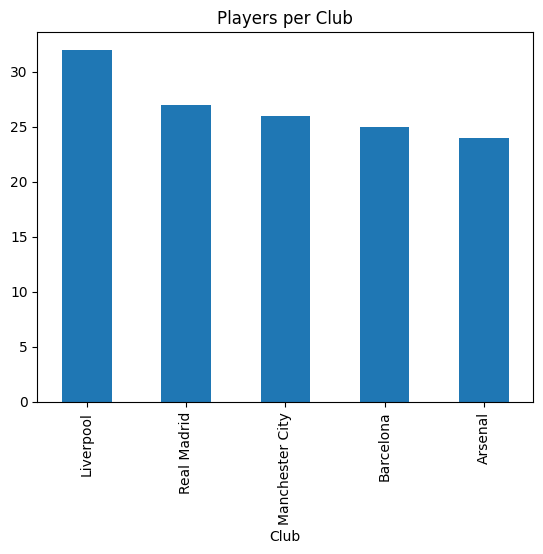

In [7]:
import matplotlib.pyplot as plt

players['Club'].value_counts().plot(kind='bar')
plt.title('Players per Club')
plt.show()

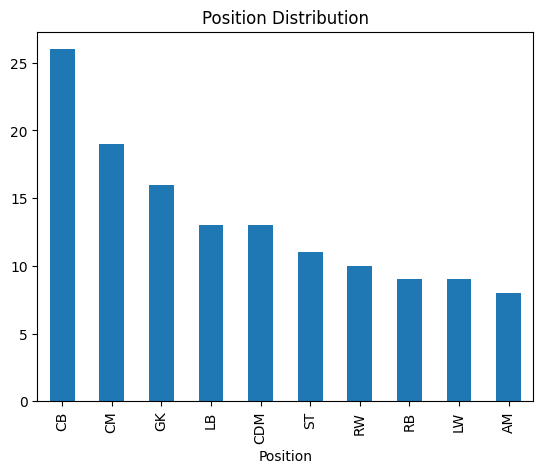

In [8]:
players['Position'].value_counts().plot(kind='bar')
plt.title('Position Distribution')
plt.show()

In [9]:
players['Nationality'].value_counts().head(10)

Nationality
Spain          34
England        27
France          9
Brazil          9
Netherlands     8
Italy           4
Germany         3
Portugal        3
Belgium         3
Norway          3
Name: count, dtype: int64

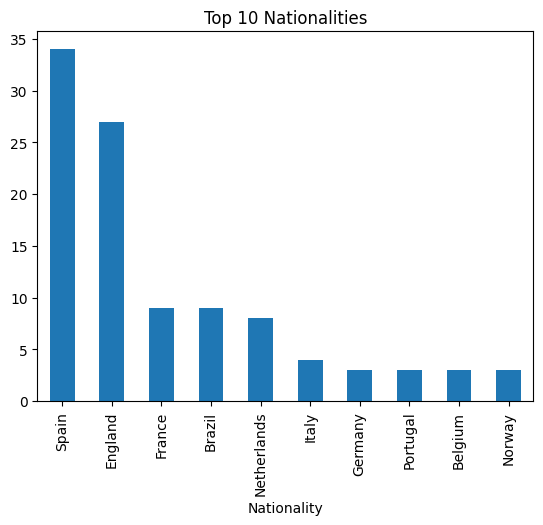

In [10]:
players['Nationality'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Nationalities')
plt.show()

In [11]:
players['Height_cm'].describe()

count    134.000000
mean     183.447761
std        7.399011
min      168.000000
25%      178.000000
50%      183.000000
75%      188.000000
max      200.000000
Name: Height_cm, dtype: float64

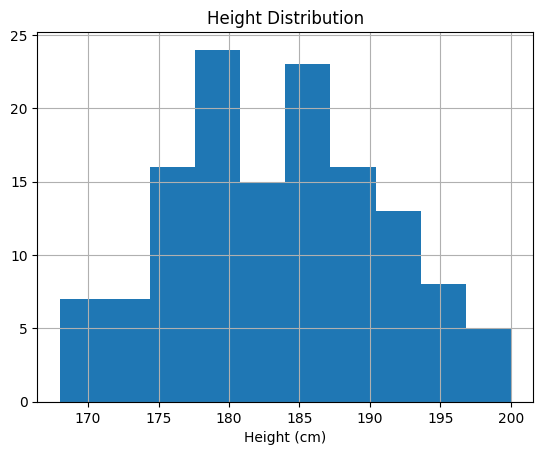

In [12]:
players['Height_cm'].hist()
plt.title('Height Distribution')
plt.xlabel('Height (cm)')
plt.show()

In [13]:
players.groupby('Position')['Height_cm'].mean().sort_values()

Position
LW     177.888889
RW     177.900000
AM     178.750000
RB     178.777778
CM     180.789474
LB     181.076923
CDM    181.769231
ST     186.545455
CB     187.653846
GK     192.500000
Name: Height_cm, dtype: float64

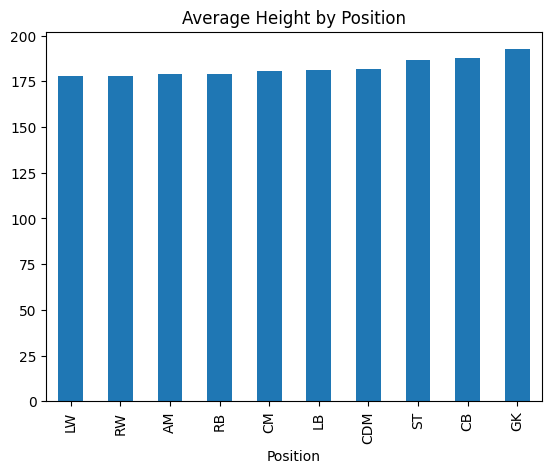

In [14]:
players.groupby('Position')['Height_cm'].mean().sort_values().plot(kind='bar')
plt.title('Average Height by Position')
plt.show()

In [15]:
merged = pd.merge(players, clubs, on=['Club','League'])

merged.head()

,Player_ID,Player_Name,Club,League,Position,Date_Of_Birth,Nationality,Height_cm,Club_ID,Country
0,P001,Alejandro Balde,Barcelona,La Liga,LB,2003-10-18,Spain,177,C001,Spain
1,P002,Andreas Christensen,Barcelona,La Liga,CB,1996-04-10,Denmark,188,C001,Spain
2,P003,Dani Olmo,Barcelona,La Liga,AM,1998-05-07,Spain,179,C001,Spain
3,P004,Diego Kochen,Barcelona,La Liga,GK,2006-03-19,United States,188,C001,Spain
4,P005,Eric García,Barcelona,La Liga,CB,2001-01-09,Spain,182,C001,Spain


In [16]:
merged['Country'].value_counts()

Country
England    82
Spain      52
Name: count, dtype: int64

In [17]:
merged.groupby('League')['Height_cm'].mean()

League
English Premier League    184.317073
La Liga                   182.076923
Name: Height_cm, dtype: float64

## Key Findings

- The dataset contains 134 players from 5 elite European clubs.
- Premier League clubs account for the majority of players.
- England and Spain are the most represented nationalities.
- Goalkeepers and center backs tend to be the tallest players.
- Most players fall between 175 cm and 190 cm in height.

This dataset demonstrates football data collection, cleaning, and exploratory analysis using Python and Pandas.